In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import bootstrap
import pickle as pkl

import flamedisx as fd

import os
import glob

import collections

2025-10-13 02:59:56.439326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760349596.453578 1327160 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760349596.458433 1327160 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760349596.472913 1327160 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760349596.472928 1327160 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760349596.472930 1327160 computation_placer.cc:177] computation placer alr

In [3]:
#Obtains the exposures and discovery bands from a directory of subfolders


def get_disco_bands(directory):
    all_exposures = []
    all_bands = []
    
    subfolders = [f.path for f in os.scandir(directory) if f.is_dir() and len(glob.glob(f'{f.path}/*.pkl')) > 0]
    for subfolder in subfolders:
        all_exposures.append(float(subfolder.split('_')[-1][:-2]))
    
        disco_sigs = pkl.load(open(f'{subfolder}/disco_sigs_0.pkl', 'rb'))
        intervals = fd.IntervalCalculator(signal_source_names=['WIMP'],
                                          stat_dists=disco_sigs)

        bands, mus = intervals.get_bands_discovery()
        all_bands.append(bands['WIMP'][mus['WIMP'][0]])

    return all_exposures, all_bands

In [4]:
#Interpolation of crossing points

def get_crossing(x, y, crit_val=5.):
    crossing_points = np.argwhere(np.diff(np.sign(y - np.ones_like(y) * crit_val)) > 0.).flatten()
    
    try:
        x_left = x[crossing_points[0]]
        x_right = x[crossing_points[0] + 1]
        y_left = y[crossing_points[0]]
        y_right = y[crossing_points[0] + 1]
    except:
        
        return x[-1]
    
    gradient = (y_right - y_left) / (x_right - x_left)

    return (crit_val - y_left) / gradient + x_left #re-arranged y-b = m(x-a) or x = (y-b)/m + a

In [5]:
files_titles = {'/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/nominal_values_0.1_sigma_1_range/benchmark_0.1_LNGS/': 'Benchmark parameters'}

[4.027045105549965, 4.470183101156007, 4.9133110017583865, 5.150091018613166, 5.468576696409727, 5.746102443042343, 5.9850937100652395, 6.135682489068665, 6.413486766182651, 6.585237249246158, 6.76373876908838, 6.921301333037241, 7.064305496508743, 7.211558612591668, 7.380411466005904, 7.471576078440533]


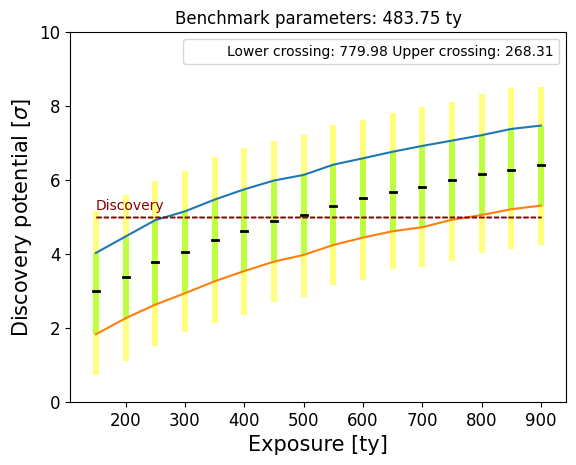

In [6]:
def produce_plot(file, title):
    exposures, bands = get_disco_bands(directory=file)
    
    plt.figure()
    delta = 5

    #medians = dict()
    medians = {}
    upper_1_sigma = {}
    lower_1_sigma = {}

    for exposure, band in zip(exposures, bands):

        plt.plot([exposure-delta, exposure+delta],
                 2*[band[0]],
                 color='k', linewidth=2)
        plt.fill_between([exposure-delta, exposure+delta],
                         2*[band[-1]], 2*[band[1]],
                         facecolor='#00ff00', alpha=0.5)
        plt.fill_between([exposure-delta, exposure+delta],
                         2*[band[-2]], 2*[band[2]],
                         facecolor='#ffff00', alpha=0.5)

        medians[exposure] = band[0]
        upper_1_sigma[exposure] = band[1]
        lower_1_sigma[exposure] = band[-1]

 
    medians = collections.OrderedDict(sorted(medians.items()))
    exposures = list(medians.keys())
    meds = list(medians.values())
    crossing = get_crossing(exposures, meds)


    upper_1_sigma  = collections.OrderedDict(sorted(upper_1_sigma.items()))
    lower_1_sigma  = collections.OrderedDict(sorted(lower_1_sigma.items()))
    uppers    = list(upper_1_sigma.values())
    lowers    = list(lower_1_sigma.values())

    #lower and upper 1 sigma crossings

    lower_crossing = get_crossing(exposures, lowers)
    upper_crossing = get_crossing(exposures, uppers)
    print(uppers)
    plt.plot(exposures, uppers)
    plt.plot(exposures, lowers)
    

    #lower and upper 1 sigma interpol lines

    plt.hlines(5., np.min(exposures), np.max(exposures), color='darkred', linestyle='--', linewidth=1)
    plt.hlines(5., np.min(exposures), np.max(exposures), color='darkred', linestyle='--', linewidth=1)


    empty = Line2D([], [], color='none', label=f'Lower crossing: {lower_crossing:.2f} Upper crossing: {upper_crossing:.2f}')
    plt.legend(handles=[empty], loc='upper right')



    plt.hlines(5., np.min(exposures), np.max(exposures), color='darkred', linestyle='--', linewidth=1)
    plt.text(np.min(exposures), 5.2, 'Discovery', color='darkred')
    plt.xlabel("Exposure [ty]")
    plt.ylabel("Discovery potential [$\sigma$]")
    plt.title(f"{title}: {crossing:.2f} ty")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0,10)
    ax = plt.gca()
    ax.xaxis.get_label().set_fontsize(15)
    ax.yaxis.get_label().set_fontsize(15)

    #plt.ylim (0., 10.)
    return lower_crossing, upper_crossing



for file, title in files_titles.items():
    low_cros, up_cros = produce_plot(file, title)

## Neutron Discovery vs Exposure

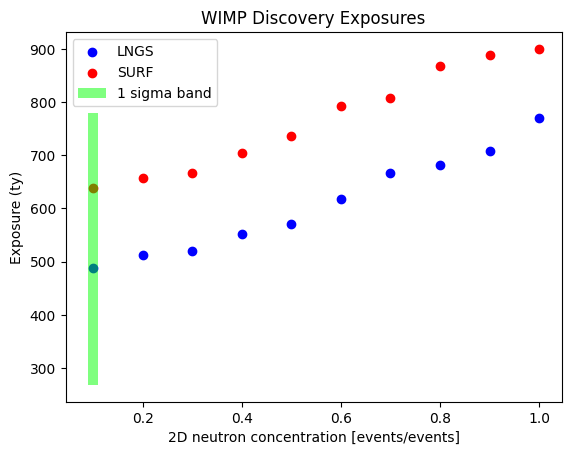

In [21]:
exposures_LNGS = np.array([487.43, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

exposures_SURF = np.array([639.38, 657.22, 666.13, 704.40, 735.76, 792.92, 807.41, 867.16, 888.60, 900])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.scatter(conc, exposures_LNGS, color='blue', label='LNGS')
plt.scatter(conc, exposures_SURF, color='red', label='SURF')

delta = 0.01
c = float(conc[0])

plt.fill_between([c - delta, c + delta],
                 2*[low_cros],
                 2*[up_cros],
                 facecolor='#00ff00', alpha=0.5, label = '1 sigma band')


plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

## Error bars - Std Dev

2.5343685604110515


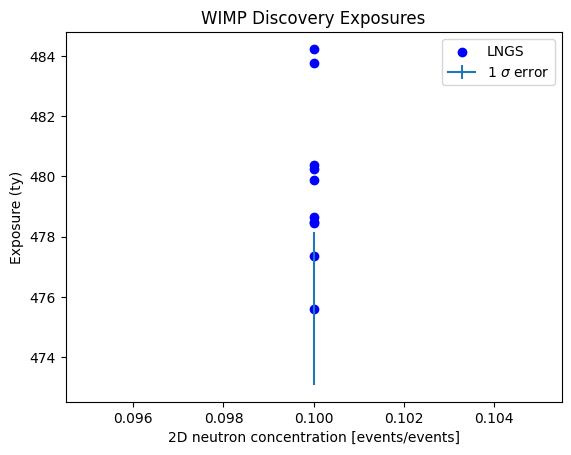

In [14]:
exposures_LNGS = np.array([475.61, 484.23, 477.35, 483.76, 479.88, 478.65, 478.45, 478.48, 480.39, 480.26])

conc = np.repeat(0.1, 10)

plt.scatter(conc, exposures_LNGS, color='blue', label='LNGS')

std_dev = np.std(exposures_LNGS)
print(std_dev)

plt.errorbar(conc[0], exposures_LNGS[0], yerr = std_dev, label = r'1 $\sigma$ error')



plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

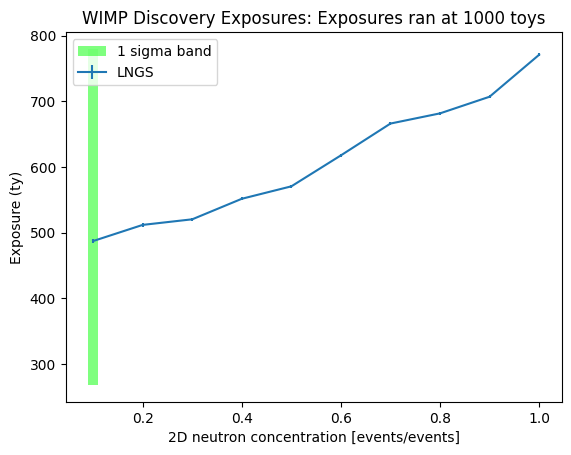

In [22]:
exposures_LNGS = np.array([487.43, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])


plt.errorbar(conc, exposures_LNGS, yerr = std_dev, label = 'LNGS')

delta = 0.01
c = float(conc[0])

plt.fill_between([c - delta, c + delta],
                 2*[low_cros],
                 2*[up_cros],
                 facecolor='#00ff00', alpha=0.5, label = '1 sigma band')


plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures: Exposures ran at 1000 toys')
plt.legend()

# Error Bars - Bootstrap

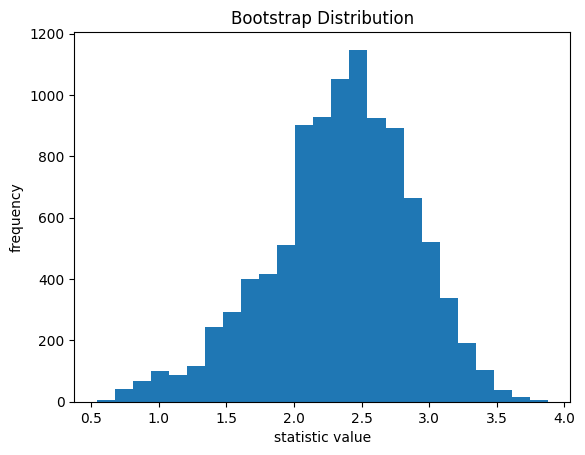

In [4]:
exposures_LNGS = np.array([475.61, 484.23, 477.35, 483.76, 479.88, 478.65, 478.45, 478.48, 480.39, 480.26])
data = exposures_LNGS


res = bootstrap((data,), np.std, confidence_level=0.68, n_resamples=10_000, random_state=np.random.default_rng())
fig, ax = plt.subplots()
ax.hist(res.bootstrap_distribution, bins=25)
ax.set_title('Bootstrap Distribution')
ax.set_xlabel('statistic value')
ax.set_ylabel('frequency')
plt.show()

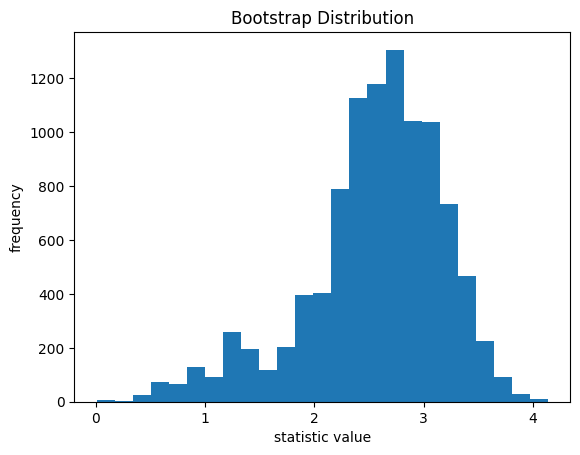

Std estimate: 2.8121141401977248
68% CI: ConfidenceInterval(low=2.468028425907754, high=3.44700753371674)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap

exposures_LNGS = np.array([475.61, 484.23, 477.35, 483.76, 479.88, 478.65, 478.45, 478.48, 480.39, 480.26])
data = exposures_LNGS

# Bootstrap expects a tuple of arrays, i.e. (data,)
res = bootstrap((data,), np.std, confidence_level=0.68, n_resamples=10_000, random_state=np.random.default_rng())

# Plot bootstrap distribution (SciPy >=1.11 only)
if hasattr(res, "bootstrap_distribution") and res.bootstrap_distribution is not None:
    boot_dist = res.bootstrap_distribution
else:
    # manually create it if not available
    rng = np.random.default_rng()
    idx = rng.integers(0, len(data), size=(10_000, len(data)))
    boot_dist = np.std(data[idx], axis=1)

fig, ax = plt.subplots()
ax.hist(boot_dist, bins=25)
ax.set_title('Bootstrap Distribution')
ax.set_xlabel('statistic value')
ax.set_ylabel('frequency')
plt.show()

print("Std estimate:", np.std(data))
CI_value = res.confidence_interval
print("68% CI:", CI_value)


In [ ]:
ci_low = res.confidence_interval.low
ci_high = res.confidence_interval.high

print(ci_high, ci_low)

std_est = np.std(data)

# yerr = np.array([[std_est - ci_low], [ci_high - std_est]])
yerr = np.array([[ci_low], [ci_high]])
print(yerr)

3.44700753371674 2.468028425907754
[[2.46802843]
 [3.44700753]]


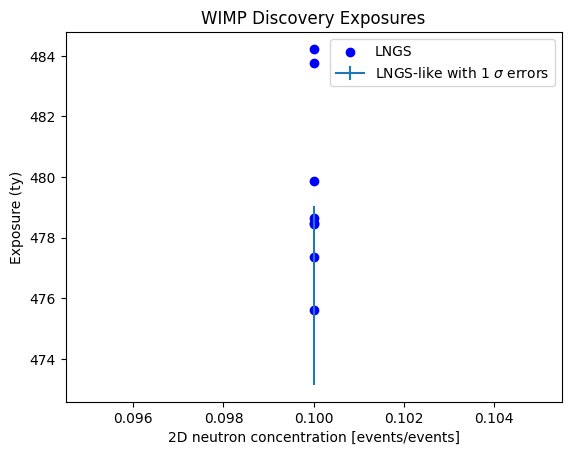

In [ ]:
exposures_LNGS = np.array([475.61, 484.23, 477.35, 483.76, 479.88, 478.65, 478.45, 478.48])

conc = np.repeat(0.1, 8)

plt.scatter(conc, exposures_LNGS, color='blue', label='LNGS')

std_dev = np.std(exposures_LNGS)


plt.errorbar(conc[0], exposures_LNGS[0], yerr = yerr, label = r'LNGS-like with 1 $\sigma$ errors')


plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

## Error bars - Bootstrap
Using the bootstrap method. Note, this only works when we have exposures very close together and with jumps in their variation (i.e. like seen [here](https://docs.google.com/presentation/d/18RPyFE89ghDNJHqrGblvD8VyR5j_uLPfgXyuzuR0P2c/edit?slide=id.g366bd46f492_0_10#slide=id.g366bd46f492_0_10))

In [ ]:
def bootstrap_1_sigma_upper(arr, percentile=85, cl=68, N=1000):

    per = np.percentile(arr, percentile) 

    pers = [np.percentile(np.random.choice(arr, size=len(arr)), percentile) for _ in range(N)]
    pers = np.array(pers)

    perd = np.percentile(pers, 0.5*(100-cl))
    peru = np.percentile(pers, 100-0.5*(100-cl))
    
    return per, perd, peru

In [ ]:
def bootstrap_1_sigma_lower(arr, percentile=15, cl=68, N=1000):

    per = np.percentile(arr, percentile) 

    pers = [np.percentile(np.random.choice(arr, size=len(arr)), percentile) for _ in range(N)]
    pers = np.array(pers)

    perd = np.percentile(pers, 0.5*(100-cl))
    peru = np.percentile(pers, 100-0.5*(100-cl))
    
    return per, perd, peru

In [ ]:
for file, title in files_titles.items():
    exposures, bands = get_disco_bands(file)
    
    print(exposures)
    print(bands)
   
    medians = dict()
    upper_lims = dict()
    lower_lims = dict ()

    for exposure, band in zip(exposures, bands):

        medians[exposure] = band[0]             #obtains the median
        upper_lims[exposure] = band[1]          #Obtains the upper limit
        lower_lims[exposure] = band[-1]         #Obtains the lower limit

    medians = collections.OrderedDict(sorted(medians.items()))
    upper_lims = collections.OrderedDict(sorted(upper_lims.items()))
    lower_lims = collections.OrderedDict(sorted(lower_lims.items()))

    upper_limits = list(upper_lims.values())
    lower_limits = list(lower_lims.values())

    exposures = list(medians.keys())
    meds = list(medians.values())
    crossing = get_crossing(exposures, meds)

[550.0, 200.0, 900.0, 800.0, 650.0, 250.0, 600.0, 400.0, 750.0, 700.0, 350.0, 150.0, 500.0, 450.0, 300.0, 850.0]
[{0: 5.305510107426052, 1: 6.413486766182651, -1: 4.240392453446672, 2: 7.489283516141284, -2: 3.1464059071525776}, {0: 3.3648573323292688, 1: 4.470183101156007, -1: 2.258867205559814, 2: 5.588453589798898, -2: 1.0999427357737552}, {0: 6.399005047795297, 1: 7.471576078440533, -1: 5.30544499358155, 2: 8.52448501795905, -2: 4.229354094957255}, {0: 6.16067019196637, 1: 7.211558612591668, -1: 5.051259516431214, 2: 8.320945092518183, -2: 4.021903962735075}, {0: 5.663065603028829, 1: 6.76373876908838, -1: 4.612711974527852, 2: 7.814920538409894, -2: 3.5793583082753297}, {0: 3.767666718275384, 1: 4.9133110017583865, -1: 2.626487673681337, 2: 5.971165200847464, -2: 1.5004743489647332}, {0: 5.521619429558676, 1: 6.585237249246158, -1: 4.439803631040695, 2: 7.610313871753018, -2: 3.287913322187354}, {0: 4.632384296990709, 1: 5.746102443042343, -1: 3.5356232619478942, 2: 6.868349381409

In [ ]:
print(meds)
print(upper_limits)
print(lower_limits)

[2.988911728872915, 3.3648573323292688, 3.767666718275384, 4.063460714004226, 4.373660486432324, 4.632384296990709, 4.878604432615024, 5.058447448351072, 5.305510107426052, 5.521619429558676, 5.663065603028829, 5.822236468918108, 6.003904979261414, 6.16067019196637, 6.279539544523535, 6.399005047795297]
[4.027045105549965, 4.470183101156007, 4.9133110017583865, 5.150091018613166, 5.468576696409727, 5.746102443042343, 5.9850937100652395, 6.135682489068665, 6.413486766182651, 6.585237249246158, 6.76373876908838, 6.921301333037241, 7.064305496508743, 7.211558612591668, 7.380411466005904, 7.471576078440533]
[1.8248208372228114, 2.258867205559814, 2.626487673681337, 2.9341736485763756, 3.2584025994342687, 3.5356232619478942, 3.7901496507394006, 3.971433863791469, 4.240392453446672, 4.439803631040695, 4.612711974527852, 4.722053980156972, 4.923215352315077, 5.051259516431214, 5.2087400967287625, 5.30544499358155]


In [ ]:
med_up, up_top, up_bottom= bootstrap_1_sigma_upper(upper_limits)
med_low, low_top, low_bottom = bootstrap_1_sigma_lower(lower_limits)

In [ ]:
print(med_up, med_low)

7.174745333570937 2.7034091674050966


In [ ]:
def produce_plot(file, title):
    exposures, bands = get_disco_bands(directory=file)
    
    plt.figure()
    delta = 5

    medians = dict()
    for exposure, band in zip(exposures, bands):

        plt.plot([exposure-delta, exposure+delta],
                 2*[band[0]],
                 color='k', linewidth=2)
        plt.fill_between([exposure-delta, exposure+delta],
                         2*[band[-1]], 2*[band[1]],
                         facecolor='#00ff00', alpha=0.5)
        plt.fill_between([exposure-delta, exposure+delta],
                         2*[band[-2]], 2*[band[2]],
                         facecolor='#ffff00', alpha=0.5)
        
        plt.fill_between([exposure-delta, exposure+delta],
                         med_low, med_up,
                         facecolor="#008cff", alpha=0.5)

        medians[exposure] = band[0]

    medians = collections.OrderedDict(sorted(medians.items()))
    exposures = list(medians.keys())
    meds = list(medians.values())
    crossing = get_crossing(exposures, meds)
    
    plt.hlines(5., np.min(exposures), np.max(exposures), color='darkred', linestyle='--', linewidth=1)
    plt.text(np.min(exposures), 5.2, 'Discovery', color='darkred')

    plt.xlabel("Exposure [ty]")
    plt.ylabel("Discovery potential [$\sigma$]")
    plt.title(f"{title}: {crossing:.2f} ty")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0,10)
    ax = plt.gca()
    ax.xaxis.get_label().set_fontsize(15)
    ax.yaxis.get_label().set_fontsize(15)

    #plt.ylim (0., 10.)

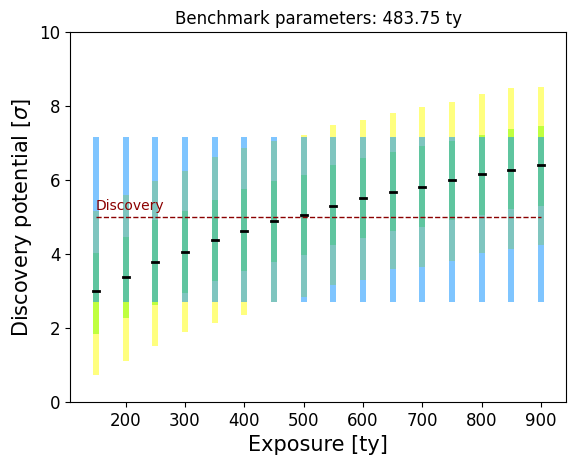

In [ ]:
for file, title in files_titles.items():
    produce_plot(file, title)